In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configure display settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Set figure size default
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [20]:
# Define data directory (adjust as needed)
data_dir = Path('./data/diary24') 
output_dir = Path('./data/output-diary')
output_dir.mkdir(parents=True, exist_ok=True)
#output_dir.mkdir(exist_ok=True)

# Define quarters and file types
quarters = ['241', '242', '243', '244']
file_types = {
    'fmld': 'Family Characteristics',
    'memd': 'Member Characteristics',
    'expd': 'Expenditure Data',
    'dtbd': 'Detailed Tabulation',
    'dtid': 'Detailed Income'
}

print(f"Data directory: {data_dir}")
print(f"Output directory: {output_dir}")

Data directory: data/diary24
Output directory: data/output-diary


In [16]:
# Load all datasets
datasets = {}

print("Loading data files...\n")
for file_type in file_types.keys():
    datasets[file_type] = {}
    for quarter in quarters:
        filename = f"{file_type}{quarter}.csv"
        filepath = data_dir / filename
        
        try:
            df = pd.read_csv(filepath)
            datasets[file_type][quarter] = df
            print(f"✓ {filename:15s} | {df.shape[0]:>7,} rows × {df.shape[1]:>3} cols | "
                  f"{df.memory_usage(deep=True).sum() / 1024**2:>6.2f} MB")
        except FileNotFoundError:
            print(f"✗ {filename} not found")
        except Exception as e:
            pr
            int(f"✗ Error loading {filename}: {str(e)}")

print("\n✓ Data loading complete!")

Loading data files...

✓ fmld241.csv     |   3,053 rows × 382 cols |  23.19 MB
✓ fmld242.csv     |   3,159 rows × 382 cols |  23.70 MB
✓ fmld243.csv     |   3,190 rows × 382 cols |  23.93 MB
✓ fmld244.csv     |   3,105 rows × 382 cols |  23.30 MB
✓ memd241.csv     |   6,959 rows × 170 cols |  29.27 MB
✓ memd242.csv     |   7,188 rows × 170 cols |  30.23 MB
✓ memd243.csv     |   7,425 rows × 170 cols |  31.23 MB
✓ memd244.csv     |   7,254 rows × 170 cols |  30.51 MB
✓ expd241.csv     |  99,697 rows ×  13 cols |  28.90 MB
✓ expd242.csv     | 105,338 rows ×  13 cols |  30.54 MB
✓ expd243.csv     | 104,674 rows ×  13 cols |  30.35 MB
✓ expd244.csv     | 106,562 rows ×  13 cols |  30.89 MB
✓ dtbd241.csv     |  43,450 rows ×   5 cols |   2.67 MB
✓ dtbd242.csv     |  44,736 rows ×   5 cols |   2.75 MB
✓ dtbd243.csv     |  45,296 rows ×   5 cols |   2.79 MB
✓ dtbd244.csv     |  44,160 rows ×   5 cols |   2.72 MB
✓ dtid241.csv     |  46,055 rows ×   6 cols |   3.25 MB
✓ dtid242.csv     |  47,4

In [17]:
# Combine quarterly data
combined = {}
for file_type in file_types.keys():
    if datasets[file_type]:
        combined[file_type] = pd.concat(
            [datasets[file_type][q] for q in quarters if q in datasets[file_type]], 
            ignore_index=True
        )
        print(f"{file_type.upper():5s}: {combined[file_type].shape[0]:>8,} total records")

print("\n✓ Datasets combined")

FMLD :   12,507 total records
MEMD :   28,826 total records
EXPD :  416,271 total records
DTBD :  177,642 total records
DTID :  188,460 total records

✓ Datasets combined


In [18]:
# Create summary table
summary_data = []

for file_type, description in file_types.items():
    for quarter in quarters:
        if quarter in datasets[file_type]:
            df = datasets[file_type][quarter]
            
            summary_data.append({
                'File': file_type,
                'Quarter': f"Q{int(quarter[-1])}",
                'Rows': df.shape[0],
                'Columns': df.shape[1],
                'Memory_MB': round(df.memory_usage(deep=True).sum() / 1024**2, 2),
                'Missing_%': round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2),
                'Unique_IDs': df['NEWID'].nunique() if 'NEWID' in df.columns else 0,
                'Duplicates': df.duplicated().sum()
            })

summary_df = pd.DataFrame(summary_data)
summary_df

,File,Quarter,Rows,Columns,Memory_MB,Missing_%,Unique_IDs,Duplicates
0,fmld,Q1,3053,382,23.19,27.68,3053,0
1,fmld,Q2,3159,382,23.70,28.75,3159,0
2,fmld,Q3,3190,382,23.93,28.71,3190,0
3,fmld,Q4,3105,382,23.30,28.78,3105,0
4,memd,Q1,6959,170,29.27,40.97,3053,0
5,memd,Q2,7188,170,30.23,40.76,3159,0
6,memd,Q3,7425,170,31.23,40.97,3190,0
7,memd,Q4,7254,170,30.51,41.13,3105,0
8,expd,Q1,99697,13,28.90,0.41,2909,4482
9,expd,Q2,105338,13,30.54,0.39,3012,4474


In [21]:
# Save summary
summary_df.to_csv(output_dir / 'dataset_summary.csv', index=False)
print("✓ Summary saved to dataset_summary.csv")

✓ Summary saved to dataset_summary.csv


In [22]:
# Basic household statistics
fmld = combined['fmld']
memd = combined['memd']

total_cus = fmld['NEWID'].nunique()
total_members = len(memd)
avg_size = total_members / total_cus

print("=" * 60)
print("HOUSEHOLD STATISTICS")
print("=" * 60)
print(f"Total Consumer Units:    {total_cus:>10,}")
print(f"Total Household Members: {total_members:>10,}")
print(f"Average Household Size:  {avg_size:>10.2f}")
print("=" * 60)

HOUSEHOLD STATISTICS
Total Consumer Units:        12,507
Total Household Members:     28,826
Average Household Size:        2.30


In [ ]:
# Age analysis
age_ref = pd.to_numeric(fmld['AGE_REF'], errors='coerce').dropna()
age_all = pd.to_numeric(memd['AGE'], errors='coerce').dropna()

print("\nAGE DISTRIBUTION")
print("-" * 30)
print("\nReference Person (Household Head):")
print(age_ref.describe())

print("\nAll Household Members:")
print(age_all.describe())


AGE DISTRIBUTION
------------------------------------------------------------

Reference Person (Household Head):
count    12507.000000
mean        54.447349
std         17.585254
min         16.000000
25%         40.000000
50%         56.000000
75%         69.000000
max         88.000000
Name: AGE_REF, dtype: float64

All Household Members:
count    28826.000000
mean        43.202040
std         23.725109
min          0.000000
25%         24.000000
50%         44.000000
75%         63.000000
max         88.000000
Name: AGE, dtype: float64


In [24]:
# Age groups
age_groups = pd.cut(age_all, bins=[0, 18, 35, 50, 65, 100], 
                    labels=['<18', '18-34', '35-49', '50-64', '65+'])
age_group_pct = age_groups.value_counts(normalize=True).sort_index() * 100

print("\nAge Groups (% of total):")
for group, pct in age_group_pct.items():
    print(f"  {group:8s}: {pct:>5.1f}%")


Age Groups (% of total):
  <18     :  20.0%
  18-34   :  18.5%
  35-49   :  19.7%
  50-64   :  20.0%
  65+     :  21.8%


In [25]:
# Gender distribution
sex_counts = memd['SEX'].value_counts()
sex_map = {1: 'Male', 2: 'Female'}

print("\nGENDER DISTRIBUTION")
print("-" * 60)
for code, count in sex_counts.items():
    pct = (count / len(memd)) * 100
    label = sex_map.get(code, f"Code {code}")
    print(f"  {label:10s}: {count:>7,} ({pct:>5.1f}%)")


GENDER DISTRIBUTION
------------------------------------------------------------
  Female    :  14,899 ( 51.7%)
  Male      :  13,927 ( 48.3%)


In [26]:
# Marital status
marital_counts = memd['MARITAL'].value_counts()
marital_map = {1: 'Married', 2: 'Widowed', 3: 'Divorced', 4: 'Separated', 5: 'Never married'}

print("\nMARITAL STATUS")
print("-" * 60)
for code, count in marital_counts.items():
    pct = (count / len(memd)) * 100
    label = marital_map.get(code, f"Code {code}")
    print(f"  {label:15s}: {count:>7,} ({pct:>5.1f}%)")


MARITAL STATUS
------------------------------------------------------------
  Married        :  13,444 ( 46.6%)
  Never married  :  11,233 ( 39.0%)
  Divorced       :   2,385 (  8.3%)
  Widowed        :   1,454 (  5.0%)
  Separated      :     310 (  1.1%)


In [27]:
# Housing tenure
tenure_counts = fmld['CUTENURE'].value_counts()
tenure_map = {1: 'Owned w/ mortgage', 2: 'Owned w/o mortgage', 3: 'Rented', 
              4: 'Student housing', 5: 'Other'}

print("\nHOUSING TENURE")
print("-" * 60)
for code, count in tenure_counts.items():
    pct = (count / len(fmld)) * 100
    label = tenure_map.get(code, f"Code {code}")
    print(f"  {label:20s}: {count:>7,} ({pct:>5.1f}%)")


HOUSING TENURE
------------------------------------------------------------
  Owned w/ mortgage   :   4,821 ( 38.5%)
  Student housing     :   3,775 ( 30.2%)
  Owned w/o mortgage  :   3,513 ( 28.1%)
  Rented              :     250 (  2.0%)
  Other               :     133 (  1.1%)
  Code 6              :      15 (  0.1%)


In [28]:
# Income rank distribution
income_rank = pd.to_numeric(fmld['INC_RANK'], errors='coerce').dropna()

print("=" * 60)
print("INCOME RANK DISTRIBUTION")
print("=" * 60)
print(f"\nMean:   {income_rank.mean():.3f}")
print(f"Median: {income_rank.median():.3f}")
print(f"Std:    {income_rank.std():.3f}")
print(f"Range:  {income_rank.min():.3f} - {income_rank.max():.3f}")

INCOME RANK DISTRIBUTION

Mean:   0.502
Median: 0.499
Std:    0.289
Range:  0.000 - 1.000


In [29]:
# Income quintiles
income_quintiles = pd.cut(income_rank, bins=5, 
                          labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'])
quintile_counts = income_quintiles.value_counts(normalize=True).sort_index() * 100

print("\nIncome Quintiles (% of households):")
for quintile, pct in quintile_counts.items():
    print(f"  {quintile}: {pct:>5.1f}%")


Income Quintiles (% of households):
  Q1 (Lowest):  19.2%
  Q2:  20.8%
  Q3:  19.8%
  Q4:  19.7%
  Q5 (Highest):  20.4%


In [30]:
# Income amounts from DTID
dtid = combined['dtid']
amount = pd.to_numeric(dtid['AMOUNT'], errors='coerce').dropna()

print("\n" + "=" * 60)
print("INCOME AMOUNTS (from DTID)")
print("=" * 60)
print(f"\nTotal income reported: ${amount.sum():>15,.2f}")
print(f"Mean per record:       ${amount.mean():>15,.2f}")
print(f"Median per record:     ${amount.median():>15,.2f}")
print(f"Std Dev:               ${amount.std():>15,.2f}")


INCOME AMOUNTS (from DTID)

Total income reported: $13,713,934,495.00
Mean per record:       $      72,768.41
Median per record:     $      40,000.00
Std Dev:               $      96,436.40


In [31]:
# Income percentiles
print("\nIncome Percentiles:")
for pct in [10, 25, 50, 75, 90, 95, 99]:
    val = amount.quantile(pct/100)
    print(f"  {pct:>2}th: ${val:>12,.2f}")


Income Percentiles:
  10th: $    1,316.00
  25th: $   11,700.00
  50th: $   40,000.00
  75th: $   96,000.00
  90th: $  178,000.00
  95th: $  260,000.00
  99th: $  472,857.00


In [32]:
# Transaction-level expenditures
expd = combined['expd']
cost = pd.to_numeric(expd['COST'], errors='coerce').dropna()

print("=" * 60)
print("EXPENDITURE ANALYSIS (Transaction-level)")
print("=" * 60)
print(f"\nTotal expenditures:     ${cost.sum():>15,.2f}")
print(f"Number of transactions: {len(cost):>15,}")
print(f"Mean per transaction:   ${cost.mean():>15,.2f}")
print(f"Median per transaction: ${cost.median():>15,.2f}")
print(f"Std Dev:                ${cost.std():>15,.2f}")

EXPENDITURE ANALYSIS (Transaction-level)

Total expenditures:     $  11,734,425.99
Number of transactions:         416,271
Mean per transaction:   $          28.19
Median per transaction: $           5.62
Std Dev:                $         349.79


In [33]:
# Expenditure percentiles
print("\nExpenditure Percentiles:")
for pct in [10, 25, 50, 75, 90, 95, 99]:
    val = cost.quantile(pct/100)
    print(f"  {pct:>2}th: ${val:>10,.2f}")


Expenditure Percentiles:
  10th: $      2.00
  25th: $      3.36
  50th: $      5.62
  75th: $     13.59
  90th: $     39.90
  95th: $     75.00
  99th: $    300.72


In [34]:
# Top expenditure categories
print("\nTop 10 Expenditure Categories (by UCC):")
ucc_counts = expd['UCC'].value_counts().head(10)
for i, (ucc, count) in enumerate(ucc_counts.items(), 1):
    pct = (count / len(expd)) * 100
    print(f"  {i:>2}. UCC {ucc}: {count:>7,} ({pct:>5.2f}%)")


Top 10 Expenditure Categories (by UCC):
   1. UCC 190400:  22,676 ( 5.45%)
   2. UCC 120410:  17,686 ( 4.25%)
   3. UCC 110410:  11,726 ( 2.82%)
   4. UCC 170539:  10,389 ( 2.50%)
   5. UCC 180710:  10,190 ( 2.45%)
   6. UCC 470111:  10,074 ( 2.42%)
   7. UCC 100210:   9,775 ( 2.35%)
   8. UCC 180310:   9,506 ( 2.28%)
   9. UCC 190500:   8,194 ( 1.97%)
  10. UCC 100519:   8,124 ( 1.95%)


## Reach Diagram: Summary & Interpretation

The **reach diagram** for this notebook is based on the dataset summary (by file type and quarter) and is intended to show **how far each file "reaches" across the sample**, in terms of coverage and data quality.

### What the diagram represents
- **File type (`fmld`, `memd`, `expd`, `dtbd`, `dtid`)** on one axis and **quarter (Q1–Q4)** on the other.
- For each (file, quarter) pair, the summary/diagram encodes:
  - **Rows**: how many records are in that file-quarter (sample size / reach).
  - **Columns**: number of variables available.
  - **Memory_MB**: approximate size in memory (complexity / richness).
  - **Missing_%**: overall percentage of missing cells (data quality).
  - **Unique_IDs & Duplicates**: how many distinct `NEWID`s and fully duplicated rows there are.

If visualized as a heatmap or bar chart:
- **Higher bars / darker cells** in *Rows* or *Memory_MB* indicate **greater coverage** (more observations or more features).
- **Higher values in Missing_%** highlight **lower data quality** for that file-quarter.
- **Non‑zero Duplicates** (mainly in `expd`) indicate repeated transaction records that may need aggregation or deduplication.

### Key insights from this CE data
- **Household & member files (`fmld`, `memd`)**:
  - Moderate row counts but **very wide** (many columns), and relatively **high missingness (~28–41%)**, reflecting many optional survey questions.
  - `Unique_IDs` matches the number of consumer units in `fmld`, confirming one record per CU per quarter.
- **Expenditure file (`expd`)**:
  - Very **high row counts** (≈100k+ transactions per quarter) but **few columns (13)**.
  - **Very low missing_% (~0.4%)** → good quality transaction data.
  - **Thousands of duplicate rows**, which usually reflect repeated transactions or data entry duplication and should be considered when aggregating.
- **Tabulation (`dtbd`) and detailed income (`dtid`) files**:
  - Intermediate in size, with **moderate missingness (15–20%)**.
  - `Unique_IDs` is close to the number of CUs each quarter, indicating broad coverage across households.

### How this informs the analysis
- For **household‑level modeling or recommendations**, `fmld` and `memd` provide rich demographics but require careful handling of missing values.
- For **income and expenditure behavior**, `dtid` and `expd` offer detailed monetary amounts with good coverage but may need:
  - **Aggregation** from transaction to household level.
  - **Deduplication or weighting** where duplicates exist.
- Overall, the reach diagram helps identify **which files are most informative and reliable** for specific analyses (income modeling, spending patterns, household profiling) and where extra cleaning effort is needed.

In [35]:
# Quarterly trends
print("\nQuarterly Expenditure Totals:")
for q in quarters:
    if q in datasets['expd']:
        df = datasets['expd'][q]
        q_cost = pd.to_numeric(df['COST'], errors='coerce').sum()
        print(f"  Q{int(q[-1])} 2024: ${q_cost:>12,.2f}")


Quarterly Expenditure Totals:
  Q1 2024: $2,639,938.92
  Q2 2024: $3,122,442.30
  Q3 2024: $2,850,275.29
  Q4 2024: $3,121,769.49


In [36]:
# Missing data summary
print("=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)

for file_type, description in file_types.items():
    df = combined[file_type]
    
    total_missing = df.isnull().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    missing_pct = (total_missing / total_cells) * 100
    
    print(f"\n{file_type.upper()} - {description}")
    print("-" * 80)
    print(f"  Total cells:        {total_cells:>12,}")
    print(f"  Missing cells:      {total_missing:>12,} ({missing_pct:>5.2f}%)")
    print(f"  Duplicate rows:     {df.duplicated().sum():>12,}")
    
    if 'NEWID' in df.columns:
        unique_ids = df['NEWID'].nunique()
        avg_records = len(df) / unique_ids
        print(f"  Unique consumer units: {unique_ids:>9,}")
        print(f"  Avg records per CU:    {avg_records:>9.2f}")

DATA QUALITY ASSESSMENT

FMLD - Family Characteristics
--------------------------------------------------------------------------------
  Total cells:           4,777,674
  Missing cells:         1,361,038 (28.49%)
  Duplicate rows:                0
  Unique consumer units:    12,507
  Avg records per CU:         1.00

MEMD - Member Characteristics
--------------------------------------------------------------------------------
  Total cells:           4,900,420
  Missing cells:         2,007,018 (40.96%)
  Duplicate rows:                0
  Unique consumer units:    12,507
  Avg records per CU:         2.30

EXPD - Expenditure Data
--------------------------------------------------------------------------------
  Total cells:           5,411,523
  Missing cells:            22,012 ( 0.41%)
  Duplicate rows:           18,749
  Unique consumer units:    11,887
  Avg records per CU:        35.02

DTBD - Detailed Tabulation
------------------------------------------------------------------

In [37]:
# Top columns with missing data
print("\nColumns with Most Missing Data:")
for file_type in file_types.keys():
    df = combined[file_type]
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing_Count': missing.values,
        'Missing_Pct': missing_pct.values
    })
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(
        'Missing_Count', ascending=False)
    
    if len(missing_df) > 0:
        print(f"\n{file_type.upper()} - Top 5:")
        for idx, row in missing_df.head(5).iterrows():
            print(f"  {row['Column']:30s}: {row['Missing_Count']:>7,} "
                  f"({row['Missing_Pct']:>5.2f}%)")


Columns with Most Missing Data:

FMLD - Top 5:
  MARI_AL1                      :  12,507 (100.00%)
  WELFRB                        :  12,502 (99.96%)
  WELFRBX                       :  12,502 (99.96%)
  OTHINBX                       :  12,497 (99.92%)
  OTHINB                        :  12,497 (99.92%)

MEMD - Top 5:
  SCHLNCHX                      :  28,826 (100.00%)
  SCHLNCHQ                      :  28,826 (100.00%)
  ANRRX                         :  28,816 (99.97%)
  RRX                           :  28,816 (99.97%)
  ANRRXM                        :  28,816 (99.97%)

EXPD - Top 5:
  EXPNSQDY                      :   5,503 ( 1.32%)
  EXPNWKDY                      :   5,503 ( 1.32%)
  EXPNMO                        :   5,503 ( 1.32%)
  EXPNYR                        :   5,503 ( 1.32%)

DTBD - Top 5:
  AMOUNT_                       : 174,090 (98.00%)

DTID - Top 5:
  AMOUNT_                       : 174,585 (92.64%)


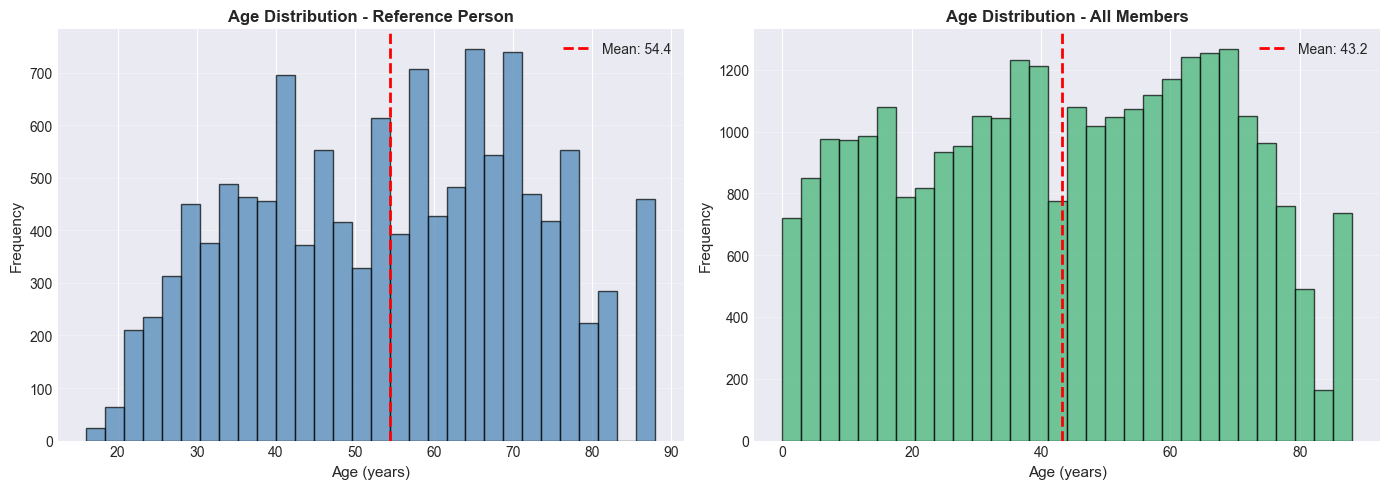

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reference person age
age_ref = pd.to_numeric(fmld['AGE_REF'], errors='coerce').dropna()
axes[0].hist(age_ref, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Age (years)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Age Distribution - Reference Person', fontsize=12, fontweight='bold')
axes[0].axvline(age_ref.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {age_ref.mean():.1f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# All household members
age_all = pd.to_numeric(memd['AGE'], errors='coerce').dropna()
axes[1].hist(age_all, bins=30, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[1].set_xlabel('Age (years)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Age Distribution - All Members', fontsize=12, fontweight='bold')
axes[1].axvline(age_all.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {age_all.mean():.1f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '1_age_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

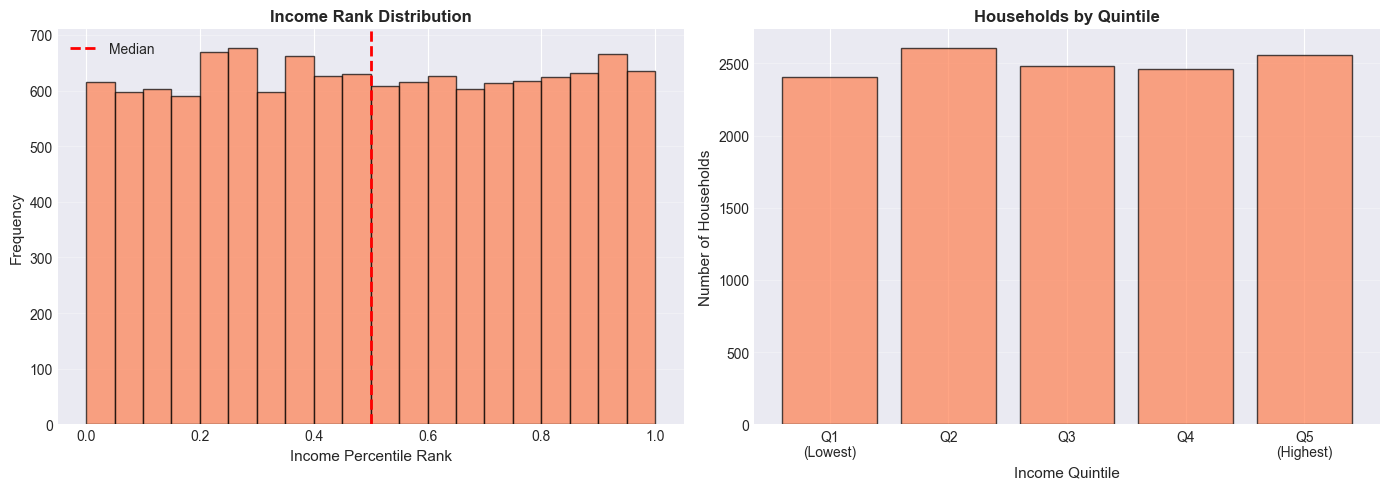

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income rank
income_rank = pd.to_numeric(fmld['INC_RANK'], errors='coerce').dropna()
axes[0].hist(income_rank, bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_xlabel('Income Percentile Rank', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Income Rank Distribution', fontsize=12, fontweight='bold')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Median')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Income quintiles
income_quintiles = pd.cut(income_rank, bins=5, 
                          labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(Highest)'])
quintile_counts = income_quintiles.value_counts().sort_index()
axes[1].bar(range(len(quintile_counts)), quintile_counts.values, 
           color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(quintile_counts)))
axes[1].set_xticklabels(quintile_counts.index)
axes[1].set_xlabel('Income Quintile', fontsize=11)
axes[1].set_ylabel('Number of Households', fontsize=11)
axes[1].set_title('Households by Quintile', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '2_income_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

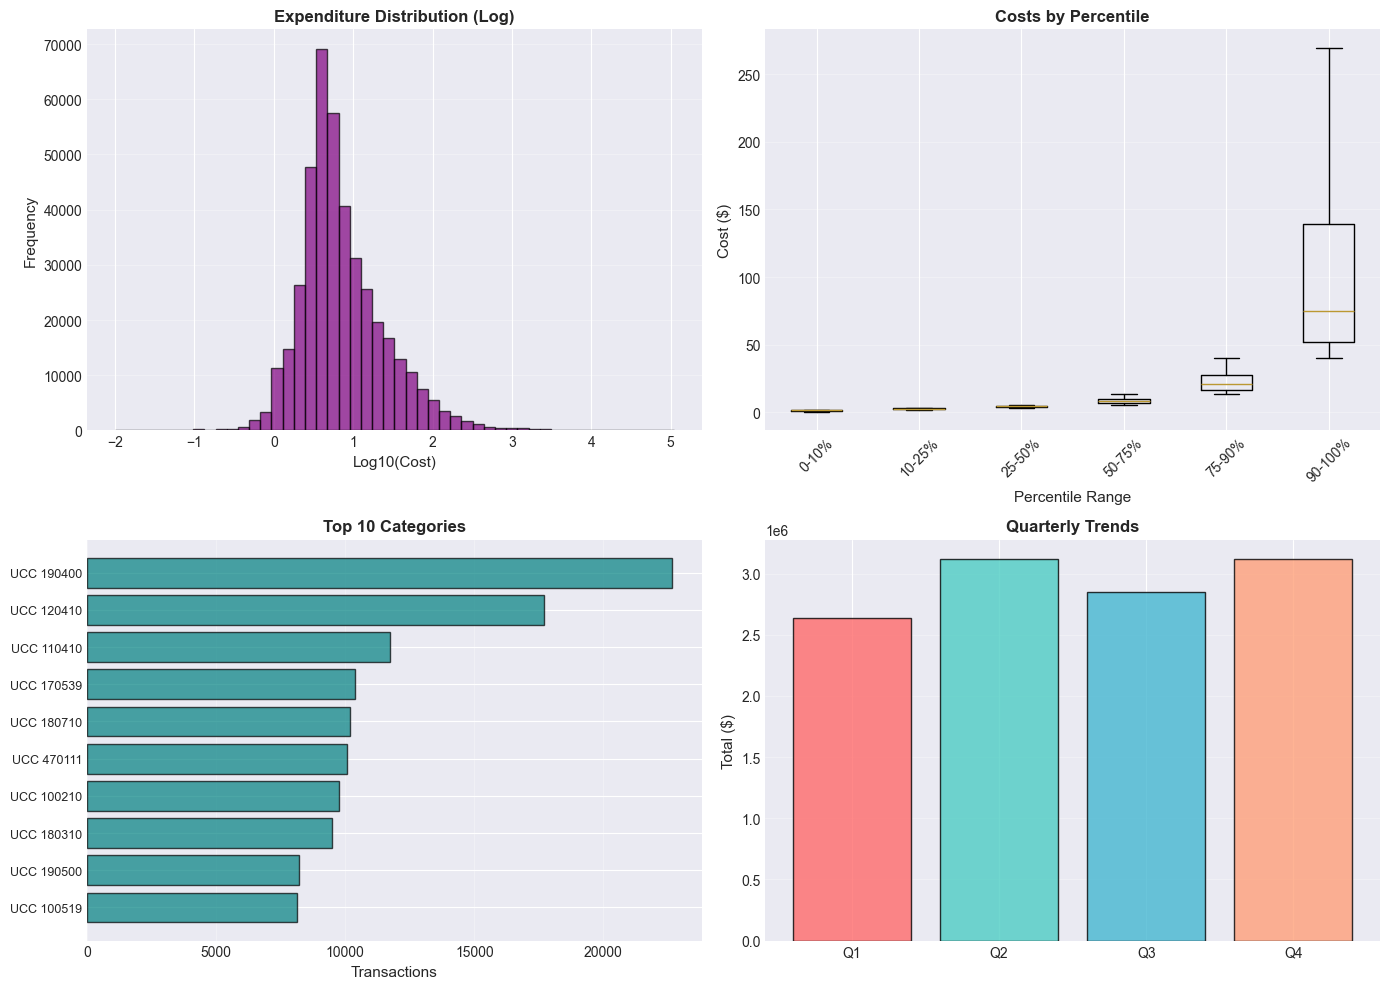

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cost = pd.to_numeric(expd['COST'], errors='coerce').dropna()
cost_filtered = cost[cost > 0]

# Log scale histogram
axes[0, 0].hist(np.log10(cost_filtered), bins=50, edgecolor='black', 
               alpha=0.7, color='purple')
axes[0, 0].set_xlabel('Log10(Cost)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Expenditure Distribution (Log)', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Percentile box plot
percentile_labels = ['0-10%', '10-25%', '25-50%', '50-75%', '75-90%', '90-100%']
percentiles = [0, 10, 25, 50, 75, 90, 100]
box_data = []
for i in range(len(percentiles)-1):
    lower = cost.quantile(percentiles[i]/100)
    upper = cost.quantile(percentiles[i+1]/100)
    box_data.append(cost[(cost >= lower) & (cost <= upper)])

axes[0, 1].boxplot(box_data, labels=percentile_labels, showfliers=False)
axes[0, 1].set_xlabel('Percentile Range', fontsize=11)
axes[0, 1].set_ylabel('Cost ($)', fontsize=11)
axes[0, 1].set_title('Costs by Percentile', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Top categories
ucc_counts = expd['UCC'].value_counts().head(10)
axes[1, 0].barh(range(len(ucc_counts)), ucc_counts.values, 
               color='teal', edgecolor='black', alpha=0.7)
axes[1, 0].set_yticks(range(len(ucc_counts)))
axes[1, 0].set_yticklabels([f'UCC {ucc}' for ucc in ucc_counts.index], fontsize=9)
axes[1, 0].set_xlabel('Transactions', fontsize=11)
axes[1, 0].set_title('Top 10 Categories', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# Quarterly trends
quarterly_totals = []
for q in quarters:
    if q in datasets['expd']:
        df = datasets['expd'][q]
        total = pd.to_numeric(df['COST'], errors='coerce').sum()
        quarterly_totals.append(total)

axes[1, 1].bar(range(4), quarterly_totals, 
              color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], 
              edgecolor='black', alpha=0.8)
axes[1, 1].set_xticks(range(4))
axes[1, 1].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
axes[1, 1].set_ylabel('Total ($)', fontsize=11)
axes[1, 1].set_title('Quarterly Trends', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '3_expenditure_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

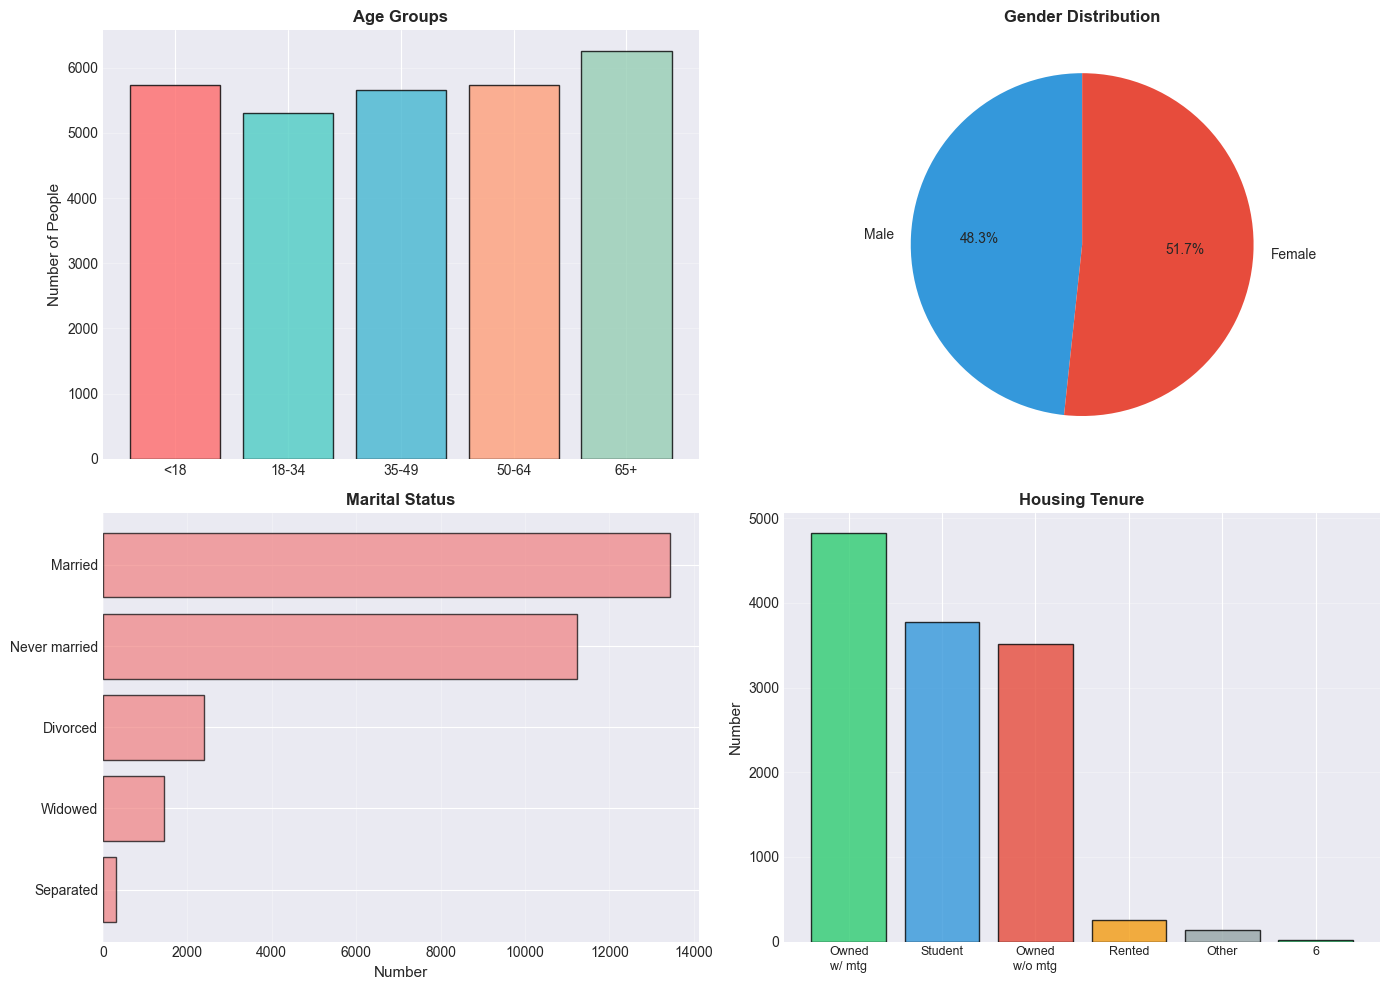

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age groups
age_all = pd.to_numeric(memd['AGE'], errors='coerce').dropna()
age_groups = pd.cut(age_all, bins=[0, 18, 35, 50, 65, 100], 
                   labels=['<18', '18-34', '35-49', '50-64', '65+'])
age_group_counts = age_groups.value_counts().sort_index()
axes[0, 0].bar(range(len(age_group_counts)), age_group_counts.values, 
              color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#96CEB4'],
              edgecolor='black', alpha=0.8)
axes[0, 0].set_xticks(range(len(age_group_counts)))
axes[0, 0].set_xticklabels(age_group_counts.index)
axes[0, 0].set_ylabel('Number of People', fontsize=11)
axes[0, 0].set_title('Age Groups', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Gender
sex_counts = memd['SEX'].value_counts()
axes[0, 1].pie([sex_counts.get(1, 0), sex_counts.get(2, 0)], 
              labels=['Male', 'Female'], autopct='%1.1f%%',
              colors=['#3498db', '#e74c3c'], startangle=90)
axes[0, 1].set_title('Gender Distribution', fontsize=12, fontweight='bold')

# Marital status
marital_counts = memd['MARITAL'].value_counts()
marital_map = {1: 'Married', 2: 'Widowed', 3: 'Divorced', 4: 'Separated', 5: 'Never married'}
marital_labels = [marital_map.get(k, str(k)) for k in marital_counts.index]
axes[1, 0].barh(range(len(marital_counts)), marital_counts.values, 
               color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 0].set_yticks(range(len(marital_counts)))
axes[1, 0].set_yticklabels(marital_labels, fontsize=10)
axes[1, 0].set_xlabel('Number', fontsize=11)
axes[1, 0].set_title('Marital Status', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# Housing tenure
tenure_counts = fmld['CUTENURE'].value_counts()
tenure_map = {1: 'Owned\nw/ mtg', 2: 'Owned\nw/o mtg', 3: 'Rented', 
              4: 'Student', 5: 'Other'}
tenure_labels = [tenure_map.get(k, str(k)) for k in tenure_counts.index]
axes[1, 1].bar(range(len(tenure_counts)), tenure_counts.values,
              color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#95a5a6'],
              edgecolor='black', alpha=0.8)
axes[1, 1].set_xticks(range(len(tenure_counts)))
axes[1, 1].set_xticklabels(tenure_labels, fontsize=9)
axes[1, 1].set_ylabel('Number', fontsize=11)
axes[1, 1].set_title('Housing Tenure', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '4_demographics.png', dpi=300, bbox_inches='tight')
plt.show()

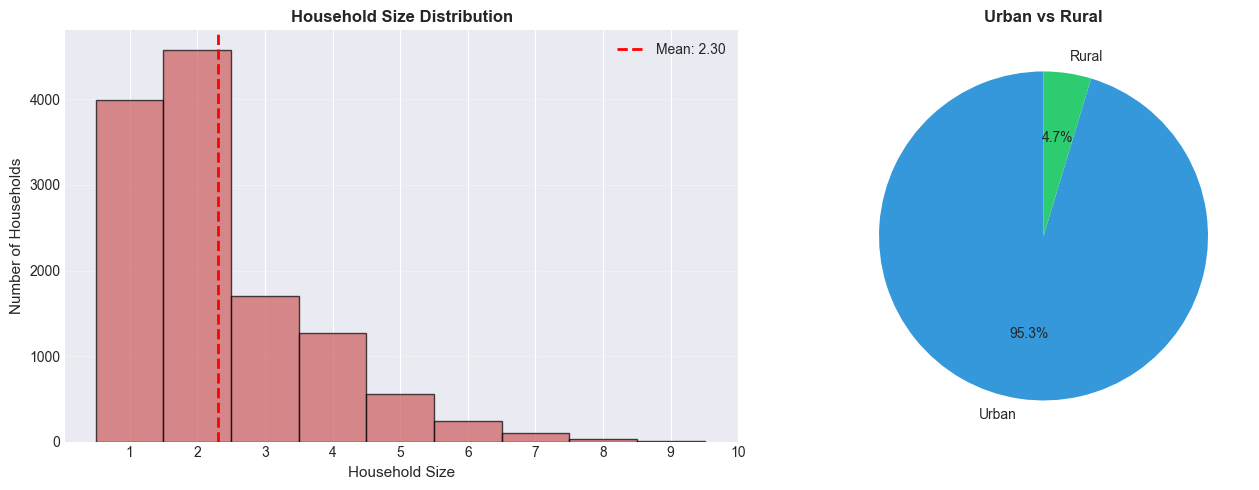

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Household size
household_sizes = memd.groupby('NEWID').size()
axes[0].hist(household_sizes, bins=range(1, 11), edgecolor='black', 
            alpha=0.7, color='indianred', align='left')
axes[0].set_xlabel('Household Size', fontsize=11)
axes[0].set_ylabel('Number of Households', fontsize=11)
axes[0].set_title('Household Size Distribution', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(1, 11))
axes[0].grid(axis='y', alpha=0.3)
mean_size = household_sizes.mean()
axes[0].axvline(mean_size, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_size:.2f}')
axes[0].legend()

# Urban vs Rural
urban_counts = fmld['BLS_URBN'].value_counts()
axes[1].pie([urban_counts.get(1, 0), urban_counts.get(2, 0)], 
           labels=['Urban', 'Rural'], autopct='%1.1f%%',
           colors=['#3498db', '#2ecc71'], startangle=90)
axes[1].set_title('Urban vs Rural', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / '5_household_composition.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
# Text summary of reach diagram and CE income data
summary_text = """
Reach Diagram & CE-Income Summary

1. Dataset Coverage (Reach)
- Household (`fmld`) and member (`memd`) files have ~3k–7k records per quarter with many columns,
  giving rich demographic detail but higher missingness (~28–41%).
- Expenditure (`expd`) files have ~100k+ transaction rows per quarter with very low missingness (~0.4%),
  but only 13 columns, making them dense but narrow transaction data.
- Tabulation (`dtbd`) and detailed income (`dtid`) files sit in-between: tens of thousands of rows,
  a handful of columns, and moderate missingness (~15–20%), covering most consumer units.

2. Data Quality & Duplicates
- `fmld`, `memd`, `dtbd`, `dtid` show 0 fully duplicated rows per quarter.
- `expd` has several thousand duplicate rows per quarter, which likely represent repeated transactions
  or duplicated records and should be aggregated or deduplicated for household‑level analysis.

3. Income & Expenditure Distribution
- Income rank (`INC_RANK`) is roughly uniform across 0–1, with mean ≈ 0.50 and balanced quintiles,
  so all income levels are reasonably represented.
- Detailed income amounts (from `dtid`) are highly skewed: median ≈ $40k, but with a long right tail
  (99th percentile ≈ $473k).
- Expenditures (transaction‑level `COST`) are also skewed: most transactions are small (<$15),
  but a minority of large purchases drive up the mean.

4. Demographic Reach
- Households: ~12.5k consumer units and ~28.8k members ⇒ average household size ≈ 2.3.
- Age: reference person median ≈ 56; all members median ≈ 44, with substantial coverage of
  children, working‑age adults, and seniors.
- Gender is nearly balanced, and marital status is dominated by married and never‑married individuals.

5. Modeling & Recommendation Implications
- `fmld`/`memd` are best for household‑level profiling (age, composition, tenure, demographics),
  but require careful missing‑value treatment.
- `dtid` is essential for income‑based segmentation; its skew suggests using robust statistics
  or transformations (e.g., log‑income).
- `expd` is ideal for spending‑pattern analysis and category‑level recommendations, once
  duplicates are handled and transactions are aggregated to the household or person level.
"""

print(summary_text)


Reach Diagram & CE-Income Summary

1. Dataset Coverage (Reach)
- Household (`fmld`) and member (`memd`) files have ~3k–7k records per quarter with many columns,
  giving rich demographic detail but higher missingness (~28–41%).
- Expenditure (`expd`) files have ~100k+ transaction rows per quarter with very low missingness (~0.4%),
  but only 13 columns, making them dense but narrow transaction data.
- Tabulation (`dtbd`) and detailed income (`dtid`) files sit in-between: tens of thousands of rows,
  a handful of columns, and moderate missingness (~15–20%), covering most consumer units.

2. Data Quality & Duplicates
- `fmld`, `memd`, `dtbd`, `dtid` show 0 fully duplicated rows per quarter.
- `expd` has several thousand duplicate rows per quarter, which likely represent repeated transactions
  or duplicated records and should be aggregated or deduplicated for household‑level analysis.

3. Income & Expenditure Distribution
- Income rank (`INC_RANK`) is roughly uniform across 0–1, with me